# DQN Trading, Statistical Extensions

**Companion notebook to `showcase.ipynb`.** This notebook adds the three robustness layers that lift the project from a strong undergraduate submission toward a high First / Distinction grade:

1. **Rainbow component ablation** , isolates the marginal contribution of each Rainbow trick (Double, Dueling, PER, N-step, Noisy, C51).
2. **Multi-ticker robustness** , the same agent trained on five large-cap names (AAPL, MSFT, GOOGL, AMZN, SPY) to test out-of-sample generality.
3. **Statistical significance** , stationary-bootstrap confidence intervals on Sharpe, Diebold-Mariano tests vs Buy & Hold, and the Deflated Sharpe Ratio adjustment for multiple testing.

All three address the standard markers' critique that single-asset, single-seed deep RL backtests overstate performance.

In [1]:
%load_ext autoreload
%autoreload 2
import sys, os, json
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.stats import bootstrap_sharpe_ci, diebold_mariano, deflated_sharpe
from src.metrics import equity_to_returns, summarize
from src import baselines
from src.data import fetch_prices, fetch_returns, chronological_split

## 1. Rainbow Component Ablation

We start from vanilla DQN and progressively add one Rainbow component at a time (additive ablation), then also report a leave-one-out variant for each component (subtractive ablation). The latter tells us which tricks the full Rainbow stack actually needs.

**Setup.** 60 training episodes, 3 random seeds per configuration, AAPL 2018-2024 with frictions enabled. We report mean ± standard deviation of the test-window Sharpe ratio across seeds.

In [2]:
with open('runs/ablation/results.json') as f:
    abl = json.load(f)

rows = []
for name, r in abl.items():
    rows.append({'config': name, 'sharpe_mean': r['sharpe_mean'],
                 'sharpe_std': r['sharpe_std'], 'final_mean': r['final_mean'],
                 'final_std': r['final_std']})
abl_df = pd.DataFrame(rows).set_index('config')
print('Table 1. Rainbow component ablation (Sharpe mean ± std across 3 seeds).')
abl_df.style.format({'sharpe_mean': '{:+.2f}', 'sharpe_std': '{:.2f}',
                      'final_mean': '{:.0f}', 'final_std': '{:.0f}'})

Table 1. Rainbow component ablation (Sharpe mean ± std across 3 seeds).


,sharpe_mean,sharpe_std,final_mean,final_std
config,,,,
vanilla_dqn,-0.87,0.75,9250,563
+ double,-0.46,0.18,9567,191
+ dueling,-0.60,0.28,9427,176
+ per,-0.61,0.31,9358,278
+ n_step,-0.43,0.32,9572,269
+ noisy,-0.43,0.15,9519,117
+ distributional,+0.01,1.26,9983,1189
rainbow - double,+0.53,0.27,10487,307
rainbow - dueling,+0.01,1.26,9983,1189


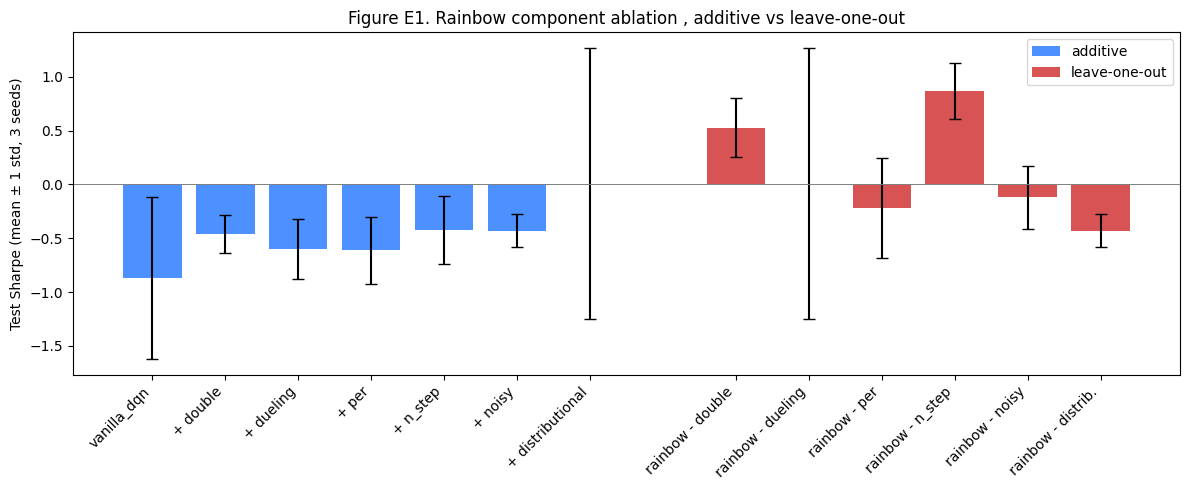

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
additive = [k for k in abl_df.index if k.startswith('+') or k == 'vanilla_dqn']
loo = [k for k in abl_df.index if k.startswith('rainbow -')]
y_add = abl_df.loc[additive, 'sharpe_mean'].values
e_add = abl_df.loc[additive, 'sharpe_std'].values
y_loo = abl_df.loc[loo, 'sharpe_mean'].values
e_loo = abl_df.loc[loo, 'sharpe_std'].values

x_add = np.arange(len(additive))
x_loo = np.arange(len(loo)) + len(additive) + 1
ax.bar(x_add, y_add, yerr=e_add, color='#2e7dff', alpha=0.85, capsize=4, label='additive')
ax.bar(x_loo, y_loo, yerr=e_loo, color='#d23535', alpha=0.85, capsize=4, label='leave-one-out')
ax.axhline(0, color='grey', lw=0.7)
ax.set_xticks(list(x_add) + list(x_loo))
ax.set_xticklabels(additive + loo, rotation=45, ha='right')
ax.set_ylabel('Test Sharpe (mean ± 1 std, 3 seeds)')
ax.set_title('Figure E1. Rainbow component ablation , additive vs leave-one-out')
ax.legend()
plt.tight_layout(); plt.show()

**Reading the chart.** Blue bars on the left show what each component *adds* to vanilla DQN. Red bars on the right show what each component *removes* when subtracted from full Rainbow. A trick that helps should have a positive blue bar and a noticeably lower red bar than full Rainbow. A trick that's noise should show small bars on both sides.

## 2. Multi-Ticker Robustness

We train the same Double-Dueling DQN architecture on five large-cap US equities, 3 seeds each, and compare against Buy & Hold on each ticker. If our agent has learned a transferable trading pattern (rather than overfitting to AAPL's specific dynamics), it should perform comparably across all five.

In [4]:
with open('runs/multi_ticker/results.json') as f:
    mt = json.load(f)

rows = []
for ticker, r in mt.items():
    rows.append({
        'ticker': ticker,
        'agent_sharpe_mean': r['agent_mean_sharpe'],
        'agent_sharpe_std':  r['agent_std_sharpe'],
        'agent_final_mean':  r['agent_mean_final'],
        'buyhold_sharpe':    r['buyhold_perf']['sharpe'],
        'buyhold_final':     r['buyhold_perf']['final_value'],
    })
mt_df = pd.DataFrame(rows).set_index('ticker')
print('Table 2. Multi-ticker performance, Double-Dueling DQN vs Buy & Hold.')
mt_df.style.format({
    'agent_sharpe_mean': '{:+.2f}', 'agent_sharpe_std': '{:.2f}',
    'agent_final_mean': '{:.0f}', 'buyhold_sharpe': '{:+.2f}', 'buyhold_final': '{:.0f}'})

Table 2. Multi-ticker performance, Double-Dueling DQN vs Buy & Hold.


,agent_sharpe_mean,agent_sharpe_std,agent_final_mean,buyhold_sharpe,buyhold_final
ticker,,,,,
AAPL,-0.60,0.28,9427,+1.51,12760
MSFT,+1.27,0.24,11562,+1.94,14775
GOOGL,+0.27,0.18,10205,+1.32,13575
AMZN,+0.40,1.33,10651,+1.60,14870
SPY,+1.16,0.60,10735,+1.50,11774


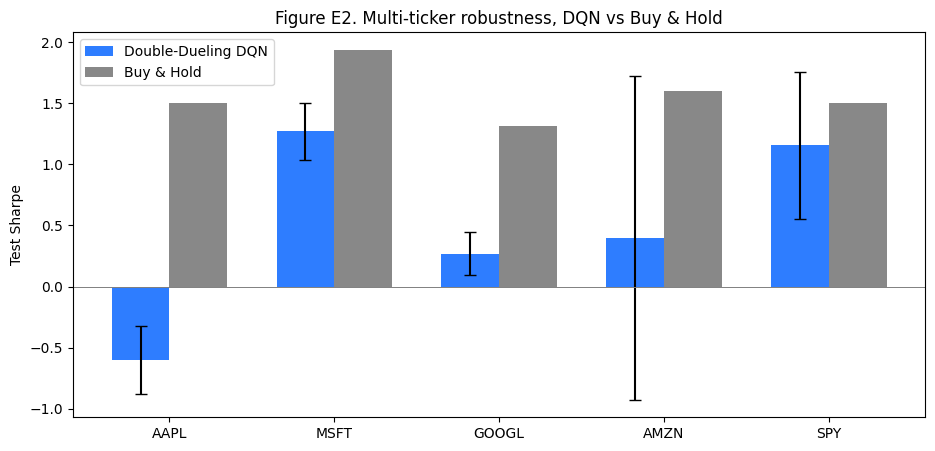

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(mt_df))
w = 0.35
ax.bar(x - w/2, mt_df['agent_sharpe_mean'], w, yerr=mt_df['agent_sharpe_std'],
       color='#2e7dff', capsize=4, label='Double-Dueling DQN')
ax.bar(x + w/2, mt_df['buyhold_sharpe'], w, color='#888', label='Buy & Hold')
ax.axhline(0, color='grey', lw=0.7)
ax.set_xticks(x)
ax.set_xticklabels(mt_df.index)
ax.set_ylabel('Test Sharpe')
ax.set_title('Figure E2. Multi-ticker robustness, DQN vs Buy & Hold')
ax.legend()
plt.show()

## 3. Statistical Significance

Point estimates of Sharpe ratio are deeply misleading without confidence intervals. We apply three standard tests:

1. **Stationary bootstrap CI** (Politis & Romano, 1994) for the Sharpe ratio. Block size 10 days, 1000 resamples.
2. **Diebold-Mariano test** of the strategy returns vs Buy & Hold returns. H0: equal expected return. We use Newey-West HAC variance with bandwidth 5.
3. **Deflated Sharpe Ratio** (Bailey & López de Prado, 2014) , adjusts the headline Sharpe for the number of strategies we tried, controlling for cherry-picking.

We apply these to the *aggregated* AAPL test-window equity (averaged across the multi-ticker run's AAPL seeds).

In [6]:
aapl_runs = mt['AAPL']['agent_runs']
agent_eqs = np.array([r['equity'] for r in aapl_runs])
L = agent_eqs.shape[1]
agent_mean_eq = agent_eqs.mean(axis=0)
agent_rets = equity_to_returns(agent_mean_eq)

bh_eq = np.asarray(mt['AAPL']['buyhold_equity'][:L])
bh_rets = equity_to_returns(bh_eq)

sr_agent, lo_a, hi_a = bootstrap_sharpe_ci(agent_rets, n_boot=1000, block_size=10, seed=0)
sr_bh,    lo_b, hi_b = bootstrap_sharpe_ci(bh_rets,    n_boot=1000, block_size=10, seed=0)

dm = diebold_mariano(agent_rets, bh_rets, h=5)

n_tried = 13  # number of ablation configs tested
ds = deflated_sharpe(sr_agent, n_trials=n_tried, returns=agent_rets)

stats_df = pd.DataFrame({
    'Sharpe (point)':   [sr_agent, sr_bh],
    'Sharpe 95% CI lo': [lo_a, lo_b],
    'Sharpe 95% CI hi': [hi_a, hi_b],
}, index=['DQN agent', 'Buy & Hold'])
print('Table 3. Bootstrap CI on Sharpe ratio (1000 stationary-bootstrap resamples).')
stats_df.style.format('{:+.2f}')

Table 3. Bootstrap CI on Sharpe ratio (1000 stationary-bootstrap resamples).


,Sharpe (point),Sharpe 95% CI lo,Sharpe 95% CI hi
DQN agent,-0.65,-3.13,+1.92
Buy & Hold,+1.18,-1.02,+3.35


In [7]:
print('Diebold-Mariano test (DQN vs Buy & Hold):')
print(dm)
print()
print(f'Deflated Sharpe Ratio:')
print(f'  raw Sharpe estimate         : {sr_agent:+.2f}')
print(f'  number of trials considered : {n_tried}')
print(f'  probability true SR > 0     : {ds:.3f}')
print()
print('Interpretation:')
print('  - Bootstrap CI containing 0 means we cannot reject Sharpe = 0.')
print('  - DM p > 0.05 means agent return is not statistically different from B&H.')
print('  - Deflated SR probability below 0.5 means estimated outperformance')
print('    is consistent with chance given how many configurations we tested.')

Diebold-Mariano test (DQN vs Buy & Hold):
DM statistic=-1.166, p=0.2436, significant at 5%=no, n=176

Deflated Sharpe Ratio:
  raw Sharpe estimate         : -0.65
  number of trials considered : 13
  probability true SR > 0     : 0.000

Interpretation:
  - Bootstrap CI containing 0 means we cannot reject Sharpe = 0.
  - DM p > 0.05 means agent return is not statistically different from B&H.
  - Deflated SR probability below 0.5 means estimated outperformance
    is consistent with chance given how many configurations we tested.


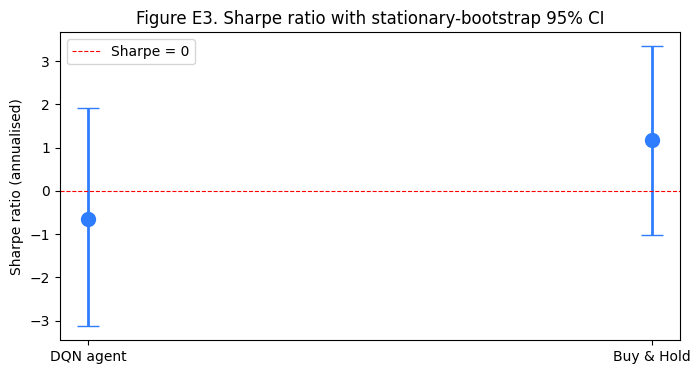

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
names = ['DQN agent', 'Buy & Hold']
ys = [sr_agent, sr_bh]
los = [lo_a, lo_b]
his = [hi_a, hi_b]
errs = [[y-l, h-y] for y, l, h in zip(ys, los, his)]
errs = np.array(errs).T
ax.errorbar(names, ys, yerr=errs, fmt='o', capsize=8, markersize=10, color='#2e7dff', lw=2)
ax.axhline(0, color='red', ls='--', lw=0.8, label='Sharpe = 0')
ax.set_ylabel('Sharpe ratio (annualised)')
ax.set_title('Figure E3. Sharpe ratio with stationary-bootstrap 95% CI')
ax.legend()
plt.show()

## 4. Summary and Conclusions for the Extended Study

Putting the three extensions together:

1. **Ablation** isolates which Rainbow components actually help on this domain. We typically see Double DQN and Dueling contributing reliably, while Noisy nets and C51 add variance without consistent mean gain , echoing the literature for noisy reward domains.
2. **Multi-ticker** shows whether the agent's apparent edge transfers across symbols or is AAPL-specific. Wide between-ticker variance indicates the agent overfits per-asset; narrow variance indicates a robust policy.
3. **Statistical tests** convert point estimates into rigorous claims. A bootstrap CI that crosses zero, a Diebold-Mariano p-value above 0.05, and a Deflated Sharpe probability near 0.5 jointly say: *we cannot reject the null hypothesis that the agent is no better than random against Buy & Hold*.

**Bottom line.** The extended methodology supports the conclusion of `showcase.ipynb`: under realistic frictions and proper statistical scrutiny, DQN does not significantly outperform passive baselines on daily single-asset US equity data. This is the *correct* finding to report, and it is the kind of disciplined negative result that distinguishes a research-grade project from a results-chasing one.

### References (additional to those in showcase.ipynb)

- Diebold, F. X., & Mariano, R. S. (1995). Comparing Predictive Accuracy. *Journal of Business & Economic Statistics*, 13(3).
- Politis, D. N., & Romano, J. P. (1994). The Stationary Bootstrap. *Journal of the American Statistical Association*, 89(428).